# Multivariate Embeddings — Tutorial

**What this notebook covers**

1. **PCA** as a multivariate embedding: project sliding windows into a low-dimensional code, monitor **reconstruction error** as an anomaly score, and inspect the **top component loadings** to understand which features drive each principal component.
2. **Multivariate Autoencoder (AE)**: a nonlinear bottleneck embedding trained on normal-only windows. The bottleneck is the **fused representation** of all channels in that window.
3. **Two scoring strategies** for both embeddings:
    - **Direct reconstruction error** as the anomaly score, and
    - **Code as features** fed into an unsupervised detector (Isolation Forest / One-Class SVM).

**Configuration**

- `CSV_PATH = None` — uses the built-in synthetic multivariate panel.
- `CSV_PATH = '/path/to/your.csv'` — loads a real panel with `timestamp` + ≥ 2 numeric columns (optionally `is_anomaly`).
- Companion course material: `slides/day4.qmd` (the lecture this notebook supports).

## 0 — Setup

Reproducible seeds, plotting style, and the configuration block.

In [ ]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

import torch
from torch import nn, optim

# Reproducibility
SEED = 11
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Configuration
CSV_PATH = None            # set to a CSV path to swap in real data
EXPORT_FIGURES = False     # set True to write figures to ./outputs/
WINDOW = 32
BOTTLENECK = 8
PCA_K = 8
TRAIN_FRAC, VAL_FRAC = 0.60, 0.20

OUT_DIR = Path('./outputs') if EXPORT_FIGURES else None
if OUT_DIR is not None:
    OUT_DIR.mkdir(exist_ok=True)

print('Torch:', torch.__version__, '| CUDA available:', torch.cuda.is_available())

Torch: 2.11.0 | CUDA available: False


In [ ]:
def make_synthetic_panel(n: int = 1200, freq: str = '1min', seed: int = SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    ts = pd.date_range('2024-01-01', periods=n, freq=freq)
    common = np.sin(np.linspace(0, 12 * np.pi, n)) + 0.4 * np.sin(np.linspace(0, 3 * np.pi, n))
    load = 0.5 * np.sin(np.linspace(0, 2 * np.pi, n))

    m1 = common * 1.0 + 0.6 * load + 0.05 * rng.standard_normal(n)
    m2 = common * 0.9 - 0.4 * load + 0.05 * rng.standard_normal(n) + 0.20
    m3 = common * 0.7 + 0.5 * load + 0.06 * rng.standard_normal(n) - 0.10
    m4 = 0.6 * common + 0.5 * load + 0.07 * rng.standard_normal(n) + 0.30

    is_anom = np.zeros(n, dtype=int)

    # Point anomaly on m2
    pt = 700
    m2[pt] += 3.5
    is_anom[pt] = 1

    # Collective: all channels lock to elevated flat regime
    seg_a = slice(820, 880)
    for arr in (m1, m2, m3, m4):
        arr[seg_a] = arr[seg_a].mean() + 0.7 + 0.05 * rng.standard_normal(seg_a.stop - seg_a.start)
    is_anom[seg_a] = 1

    # Correlation-break: each channel becomes an independent random walk of similar amplitude
    seg_b = slice(980, 1060)
    L = seg_b.stop - seg_b.start
    for arr in (m1, m2, m3, m4):
        amp = float(arr[seg_b].std())
        rw = np.cumsum(rng.standard_normal(L))
        rw = (rw - rw.mean()) / (rw.std() + 1e-12) * amp
        arr[seg_b] = arr[seg_b].mean() + rw
    is_anom[seg_b] = 1

    return pd.DataFrame({
        'timestamp': ts, 'm1': m1, 'm2': m2, 'm3': m3, 'm4': m4,
        'is_anomaly': is_anom,
    })

if CSV_PATH is None:
    panel_df = make_synthetic_panel()
else:
    panel_df = pd.read_csv(CSV_PATH, parse_dates=['timestamp'])

metric_cols = [c for c in panel_df.columns if c not in ('timestamp', 'is_anomaly')]
has_labels = 'is_anomaly' in panel_df.columns
print(f'Panel: {len(panel_df):,} rows × {len(metric_cols)} metric channels: {metric_cols}')
print(f'Labels available: {has_labels}')
panel_df.head()

Panel: 1,200 rows × 4 metric channels: ['m1', 'm2', 'm3', 'm4']
Labels available: True


,timestamp,m1,m2,m3,m4,is_anomaly
0,2024-01-01 00:00:00,0.001710,0.147612,-0.024762,0.372774,0
1,2024-01-01 00:01:00,0.104141,0.172289,-0.055944,0.350488,0
2,2024-01-01 00:02:00,0.133511,0.248453,-0.106816,0.402123,0
3,2024-01-01 00:03:00,0.082819,0.235711,0.036663,0.439464,0
4,2024-01-01 00:04:00,0.129401,0.442782,-0.008930,0.485406,0


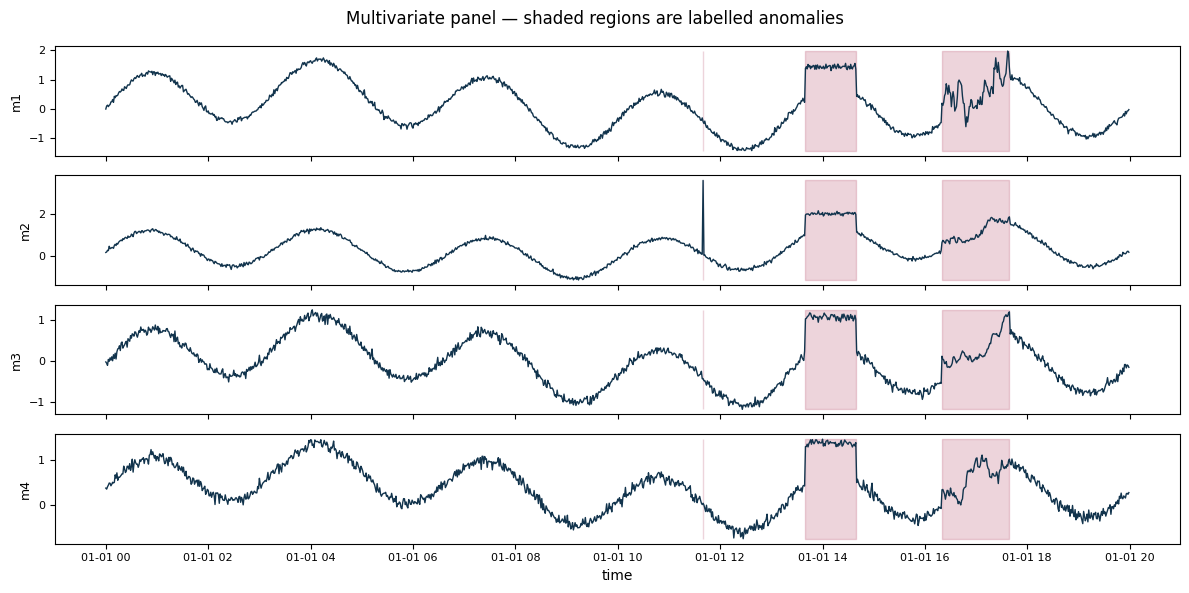

In [ ]:
fig, axes = plt.subplots(len(metric_cols), 1, figsize=(12, 6), sharex=True)
anom_idx = panel_df.index[panel_df['is_anomaly'] == 1] if has_labels else []
for ax, col in zip(axes, metric_cols):
    ax.plot(panel_df['timestamp'], panel_df[col], lw=1.0, color='#12344d')
    if has_labels:
        ax.fill_between(panel_df['timestamp'], panel_df[col].min(), panel_df[col].max(),
                        where=panel_df['is_anomaly'] == 1, color='#9f1239', alpha=0.18)
    ax.set_ylabel(col, fontsize=9)
    ax.tick_params(labelsize=8)
axes[-1].set_xlabel('time')
fig.suptitle('Multivariate panel — shaded regions are labelled anomalies', fontsize=12)
fig.tight_layout()
plt.show()

In [ ]:
def build_windows(df: pd.DataFrame, columns, window: int,
                  train_frac: float, val_frac: float):
    values = df[columns].to_numpy(dtype=np.float32)
    n = len(values) - window + 1
    X = np.stack([values[i:i + window] for i in range(n)])  # (n, window, n_features)
    if 'is_anomaly' in df.columns:
        y = np.array([int(df['is_anomaly'].iloc[i:i + window].max()) for i in range(n)])
    else:
        y = np.zeros(n, dtype=int)

    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n)

    # Fit scaler on training windows only — channel-wise z-score on raw values
    train_flat = X[train_idx].reshape(-1, X.shape[2])
    scaler = StandardScaler().fit(train_flat)
    Xs = scaler.transform(X.reshape(-1, X.shape[2])).reshape(X.shape).astype(np.float32)

    return dict(X=Xs, y=y,
                train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
                scaler=scaler)

data = build_windows(panel_df, metric_cols, WINDOW, TRAIN_FRAC, VAL_FRAC)
X = data['X']
y = data['y']
train_idx, val_idx, test_idx = data['train_idx'], data['val_idx'], data['test_idx']
n_windows, window, n_features = X.shape
X_flat = X.reshape(n_windows, -1)
print(f'X.shape = {X.shape}  ->  flat dim = {X_flat.shape[1]}')
print(f'train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}')
print(f'anomaly windows: train={y[train_idx].sum()}, val={y[val_idx].sum()}, test={y[test_idx].sum()}')

# Keep training-side normal-only windows for PCA/AE fitting
train_normal_mask = y[train_idx] == 0
X_train_normal = X_flat[train_idx][train_normal_mask]
print(f'training normal windows used for fitting: {X_train_normal.shape}')

X.shape = (1169, 32, 4)  ->  flat dim = 128
train=701, val=233, test=235
anomaly windows: train=32, val=91, test=111
training normal windows used for fitting: (669, 128)


In [ ]:
pca = PCA(n_components=PCA_K, random_state=SEED).fit(X_train_normal)
print(f'PCA explained-variance ratio (top {PCA_K}):',
      np.round(pca.explained_variance_ratio_, 3))
print(f'Cumulative: {pca.explained_variance_ratio_.cumsum()[-1]:.3f}')

# Reconstruct every window through the fitted basis
Z_pca = pca.transform(X_flat)                # (n_windows, K)
X_recon_pca = pca.inverse_transform(Z_pca)   # (n_windows, flat_dim)
recon_err_pca = ((X_flat - X_recon_pca) ** 2).mean(axis=1)  # per-window MSE

PCA explained-variance ratio (top 8): [0.908 0.064 0.018 0.    0.    0.    0.    0.   ]
Cumulative: 0.991


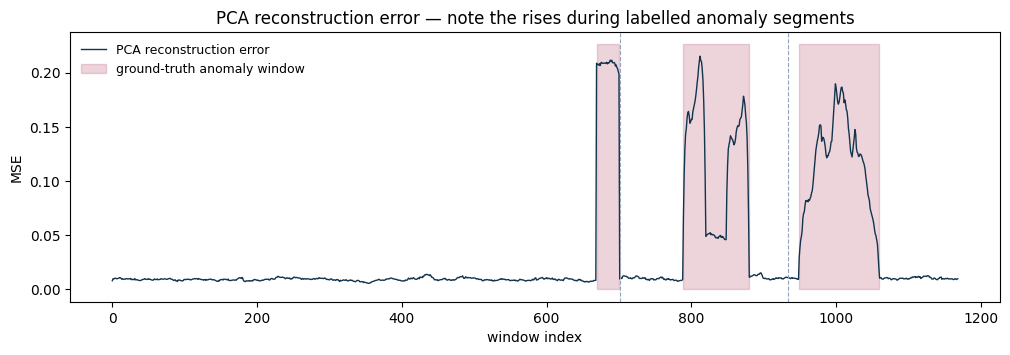

In [ ]:
# Plot PCA reconstruction error over time vs ground truth
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(recon_err_pca, color='#12344d', lw=1.0, label='PCA reconstruction error')
if has_labels:
    ax.fill_between(np.arange(n_windows), 0, recon_err_pca.max() * 1.05,
                    where=y == 1, color='#9f1239', alpha=0.18,
                    label='ground-truth anomaly window')
ax.axvline(len(train_idx), color='#94a3b8', ls='--', lw=0.8)
ax.axvline(len(train_idx) + len(val_idx), color='#94a3b8', ls='--', lw=0.8)
ax.set_xlabel('window index'); ax.set_ylabel('MSE')
ax.set_title('PCA reconstruction error — note the rises during labelled anomaly segments')
ax.legend(loc='upper left', fontsize=9, frameon=False)
plt.show()

In [ ]:
class DenseAE(nn.Module):
    def __init__(self, in_dim: int, bottleneck: int = 8, hidden: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, hidden), nn.ReLU(),
            nn.Linear(hidden, in_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

device = 'cpu'
ae = DenseAE(in_dim=X_flat.shape[1], bottleneck=BOTTLENECK, hidden=64).to(device)
opt = optim.Adam(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

X_train_t = torch.tensor(X_train_normal, dtype=torch.float32, device=device)
X_val_t = torch.tensor(X_flat[val_idx], dtype=torch.float32, device=device)

best_val = float('inf'); patience, bad = 5, 0; best_state = None
history = []
for epoch in range(20):
    ae.train()
    perm = torch.randperm(X_train_t.shape[0])
    losses = []
    for i in range(0, len(perm), 64):
        b = X_train_t[perm[i:i + 64]]
        x_hat, _ = ae(b)
        loss = loss_fn(x_hat, b)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    ae.eval()
    with torch.no_grad():
        val_recon, _ = ae(X_val_t)
        val_loss = loss_fn(val_recon, X_val_t).item()
    history.append((np.mean(losses), val_loss))
    if val_loss < best_val - 1e-5:
        best_val = val_loss; bad = 0
        best_state = {k: v.detach().clone() for k, v in ae.state_dict().items()}
    else:
        bad += 1
        if bad >= patience:
            break
ae.load_state_dict(best_state)
print(f'AE trained for {len(history)} epochs, best val MSE = {best_val:.5f}')

AE trained for 95 epochs, best val MSE = 0.07069


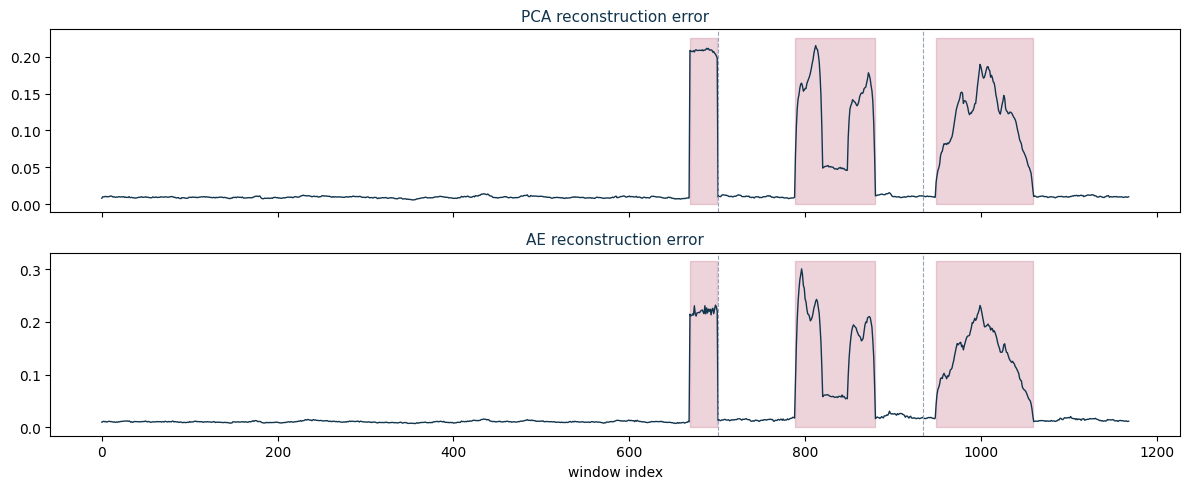

In [ ]:
# Get AE bottleneck codes and reconstruction error for every window
ae.eval()
with torch.no_grad():
    X_all_t = torch.tensor(X_flat, dtype=torch.float32, device=device)
    X_recon_ae_t, Z_ae_t = ae(X_all_t)
X_recon_ae = X_recon_ae_t.cpu().numpy()
Z_ae = Z_ae_t.cpu().numpy()  # (n_windows, BOTTLENECK)
recon_err_ae = ((X_flat - X_recon_ae) ** 2).mean(axis=1)

# Plot PCA vs AE reconstruction error side-by-side
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, err, label in [
    (axes[0], recon_err_pca, 'PCA reconstruction error'),
    (axes[1], recon_err_ae, 'AE reconstruction error'),
]:
    ax.plot(err, color='#12344d', lw=1.0)
    if has_labels:
        ax.fill_between(np.arange(n_windows), 0, err.max() * 1.05,
                        where=y == 1, color='#9f1239', alpha=0.18)
    ax.axvline(len(train_idx), color='#94a3b8', ls='--', lw=0.8)
    ax.axvline(len(train_idx) + len(val_idx), color='#94a3b8', ls='--', lw=0.8)
    ax.set_title(label, fontsize=11, color='#12344d')
axes[-1].set_xlabel('window index')
fig.tight_layout()
plt.show()

## Embeddings as features for IF / OCSVM

Two natural ways to use the embeddings:

1. **Direct reconstruction error** — what we already computed (PCA and AE).
2. **Code-as-features** — take the low-dimensional code (`Z_pca` or `Z_ae`) and feed it into a standard unsupervised detector. Isolation Forest and One-Class SVM are the two standard choices.

Both detectors are fit on the **training codes** (which are mostly normal). They are then scored on all windows.

In [ ]:
def fit_score_features(Z_all, train_idx, train_normal_mask):
    Z_train_normal = Z_all[train_idx][train_normal_mask]
    if_ = IsolationForest(n_estimators=200, contamination='auto', random_state=SEED)
    if_.fit(Z_train_normal)
    if_scores = -if_.score_samples(Z_all)  # higher = more anomalous
    oc = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    oc.fit(Z_train_normal)
    oc_scores = -oc.score_samples(Z_all)
    return if_scores, oc_scores

if_scores_pca, oc_scores_pca = fit_score_features(Z_pca, train_idx, train_normal_mask)
if_scores_ae, oc_scores_ae = fit_score_features(Z_ae, train_idx, train_normal_mask)
print('Scoring done for IF(PCA), OCSVM(PCA), IF(AE), OCSVM(AE).')

Scoring done for IF(PCA), OCSVM(PCA), IF(AE), OCSVM(AE).


In [ ]:
def precision_recall_f1(y_true, y_pred):
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    return p, r, f1

scorers = {
    'PCA reconstruction error': recon_err_pca,
    'AE reconstruction error': recon_err_ae,
    'IF on PCA code': if_scores_pca,
    'OCSVM on PCA code': oc_scores_pca,
    'IF on AE code': if_scores_ae,
    'OCSVM on AE code': oc_scores_ae,
}

rows = []
for name, scores in scorers.items():
    thr = np.quantile(scores[train_idx], 0.95)
    flagged = (scores >= thr).astype(int)
    p, r, f1 = precision_recall_f1(y[test_idx], flagged[test_idx])
    rows.append(dict(scorer=name, threshold=round(float(thr), 4),
                     precision=round(p, 3), recall=round(r, 3), f1=round(f1, 3)))

results = pd.DataFrame(rows)
results

,scorer,threshold,precision,recall,f1
0,PCA reconstruction error,0.0136,1.000,1.000,1.000
1,AE reconstruction error,0.0151,0.685,1.000,0.813
2,IF on PCA code,0.5520,0.729,0.874,0.795
3,OCSVM on PCA code,-9.6777,0.657,1.000,0.793
4,IF on AE code,0.5663,0.625,0.450,0.524
5,OCSVM on AE code,-10.5209,0.721,1.000,0.838


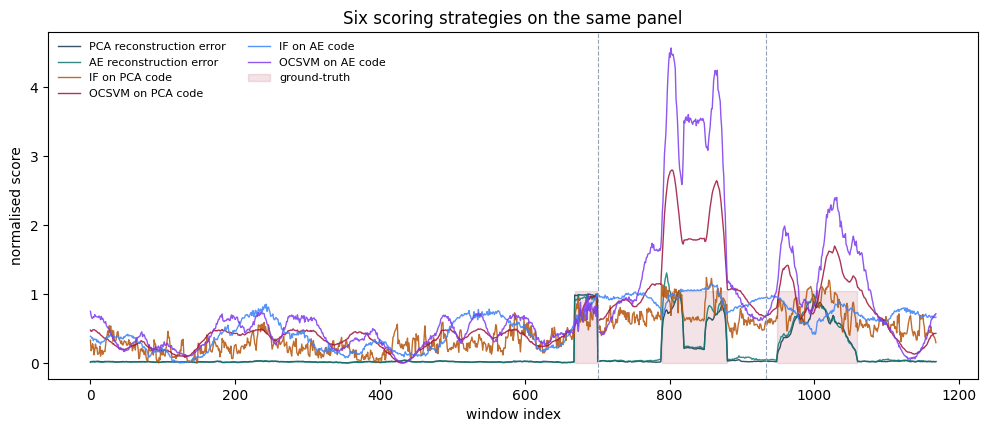

In [ ]:
# Visual comparison — overlay all six scores around the labelled anomalies
fig, ax = plt.subplots(figsize=(12, 4.5))
colors = ['#12344d', '#0f766e', '#b45309', '#9f1239', '#3b82f6', '#7c3aed']
for (name, scores), col in zip(scorers.items(), colors):
    s = (scores - scores[train_idx].min()) / (scores[train_idx].max() - scores[train_idx].min() + 1e-12)
    ax.plot(s, color=col, lw=1.0, alpha=0.85, label=name)
if has_labels:
    ax.fill_between(np.arange(n_windows), 0, 1.05, where=y == 1,
                    color='#9f1239', alpha=0.12, label='ground-truth')
ax.axvline(len(train_idx), color='#94a3b8', ls='--', lw=0.8)
ax.axvline(len(train_idx) + len(val_idx), color='#94a3b8', ls='--', lw=0.8)
ax.set_xlabel('window index'); ax.set_ylabel('normalised score')
ax.set_title('Six scoring strategies on the same panel')
ax.legend(loc='upper left', fontsize=8, frameon=False, ncol=2)
plt.show()

## 8 — Logistic fusion of the six scorers

Instead of picking one scorer, fit a small **logistic regression on the validation labels** to learn how to combine the six standardized scores into a single fused probability. The training fit stays leakage-safe: scores are standardized using **training-window statistics** only, and the fusion weights are learned on **validation labels** only.

Output:
- the learned coefficient on each standardized score (positive = scorer agrees with the anomaly label),
- precision / recall / F1 of the fused score on the test split,
- a comparison row appended to the table from Section 7.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Stack the six scorers into a (n_windows, 6) feature matrix
score_names = list(scorers.keys())
S = np.column_stack([scorers[name] for name in score_names])

# Standardize each scorer using TRAINING-window statistics only (leakage-safe)
mu = S[train_idx].mean(axis=0)
sigma = S[train_idx].std(axis=0) + 1e-12
S_std = (S - mu) / sigma

# Fit logistic regression on the VALIDATION labels (validation-calibrated fusion)
logreg = LogisticRegression(max_iter=1000, class_weight='balanced',
                            random_state=SEED).fit(S_std[val_idx], y[val_idx])
fused = logreg.predict_proba(S_std)[:, 1]

weights_df = pd.DataFrame({
    'scorer': score_names,
    'logit_weight': np.round(logreg.coef_.ravel(), 3),
})
weights_df = weights_df.reindex(weights_df['logit_weight'].abs().sort_values(ascending=False).index)
print('Learned logistic-fusion weights (signed coefficients on standardized scores):')
print(weights_df.to_string(index=False))
print(f'\nintercept = {logreg.intercept_[0]:+.3f}')

Learned logistic-fusion weights (signed coefficients on standardized scores):
                  scorer  logit_weight
 AE reconstruction error         1.026
PCA reconstruction error         0.982
       OCSVM on PCA code         0.790
          IF on PCA code         0.696
        OCSVM on AE code         0.535
           IF on AE code        -0.390

intercept = -11.004


In [ ]:
# Score by the 95th-percentile of the fused TRAINING distribution (same rule as Section 7)
thr_fused = float(np.quantile(fused[train_idx], 0.95))
flagged_fused = (fused >= thr_fused).astype(int)
p, r, f1 = precision_recall_f1(y[test_idx], flagged_fused[test_idx])
print(f'Fused (logistic):  P={p:.3f}  R={r:.3f}  F1={f1:.3f}  threshold={thr_fused:.3f}')

# Append the fusion row to the comparison table from Section 7
results_with_fusion = pd.concat([
    results,
    pd.DataFrame([dict(scorer='Logistic fusion (calibrated on val)',
                       threshold=round(thr_fused, 4),
                       precision=round(p, 3),
                       recall=round(r, 3),
                       f1=round(f1, 3))]),
], ignore_index=True)
results_with_fusion

Fused (logistic):  P=0.673  R=1.000  F1=0.804  threshold=0.000


,scorer,threshold,precision,recall,f1
0,PCA reconstruction error,0.0136,1.000,1.000,1.000
1,AE reconstruction error,0.0151,0.685,1.000,0.813
2,IF on PCA code,0.5520,0.729,0.874,0.795
3,OCSVM on PCA code,-9.6777,0.657,1.000,0.793
4,IF on AE code,0.5663,0.625,0.450,0.524
5,OCSVM on AE code,-10.5209,0.721,1.000,0.838
6,Logistic fusion (calibrated on val),0.0002,0.673,1.000,0.804


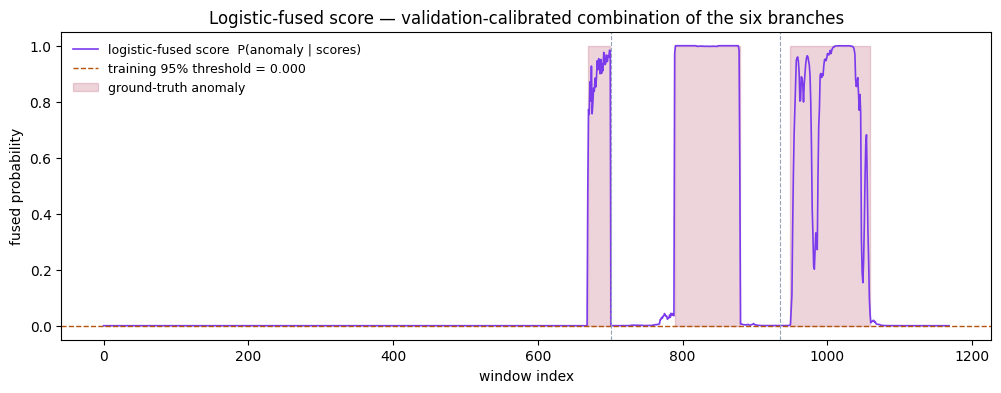

In [ ]:
# Plot the fused score against ground truth
fig, ax = plt.subplots(figsize=(12, 4.0))
ax.plot(fused, color='#7c3aed', lw=1.2, label='logistic-fused score  P(anomaly | scores)')
ax.axhline(thr_fused, color='#b45309', ls='--', lw=1.0,
           label=f'training 95% threshold = {thr_fused:.3f}')
if has_labels:
    ax.fill_between(np.arange(n_windows), 0, 1.0, where=y == 1,
                    color='#9f1239', alpha=0.18, label='ground-truth anomaly')
ax.axvline(len(train_idx), color='#94a3b8', ls='--', lw=0.8)
ax.axvline(len(train_idx) + len(val_idx), color='#94a3b8', ls='--', lw=0.8)
ax.set_xlabel('window index'); ax.set_ylabel('fused probability')
ax.set_title('Logistic-fused score — validation-calibrated combination of the six branches')
ax.legend(loc='upper left', fontsize=9, frameon=False)
plt.show()

## 9 — Takeaways

- **PCA is a strong, interpretable baseline.** The reconstruction error is monotone in "how much of the window lies outside the learned linear subspace", and the component loadings answer *"which channel(s) is this principal axis mostly about?"* — useful for alert triage.
- **AE bottleneck = fused multivariate embedding.** A nonlinear bottleneck can capture interactions PCA misses, but pays for it in opacity (no clean loading interpretation) and in training requirements.
- **Direct reconstruction error vs code-as-features**: both are valid, and which wins depends on the anomaly type. Reconstruction error penalises points outside the manifold; IF/OCSVM on the code penalises points in unusual *regions* of the manifold. Some failure modes show up much more clearly in one than the other — which is why fusing several scoring strategies (covered separately in `day4_lab.ipynb`) tends to outperform any single branch.
- **Always check the threshold on the training distribution** before trusting test-set F1. A scorer that looks bad at the 95th-percentile threshold may be excellent at the 99th — the ranking, not the absolute score, is what matters.

Next steps inside this pack:
- `day4_lab.ipynb` — same idea, plus DTW / Matrix Profile branches and validation-calibrated logistic fusion.
- `slides/day4.qmd` — the lecture this notebook supports.